In [2]:
# this path append is for binder only
import sys
sys.path.append("../../")

#spectrome modules
from spectrome.utils import functions, path
from spectrome.brain import Brain

from spectrome.forward import ntf_local_stimulus as nt_stim
from spectrome.forward import ntf_local as nt_nostim
from spectrome.forward import ntf_local_stimulus as nt_stim

#generic modules
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import pickle as pkl
from scipy import stats
from scipy.io import loadmat
from scipy.stats import pearsonr, spearmanr
from scipy.io import savemat


# from fooof import FOOOF
from fooof.plts.annotate import plot_annotated_model

from statsmodels.stats.multicomp import MultiComparison
import statsmodels.stats
import statsmodels.api as sm
from statsmodels.stats import weightstats
from statsmodels.stats.multitest import fdrcorrection
import pingouin as pg
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import mannwhitneyu

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [3]:
##all the sessions data of MEG
data1=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess1.mat")
data2=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess2.mat")
data3=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess3.mat")
data4=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess4.mat")


##all the sessions mi 
sess1_mi_avg=data1['Avg_MI_MEG_DK']
sess2_mi_avg=data2['Avg_MI_MEG_DK']
sess3_mi_avg=data3['Avg_MI_MEG_DK']
sess4_mi_avg=data4['Avg_MI_EEG_DK']

##all the sessions resting state
sess1_rest_avg=data1['Avg_RS1_MEG_DK']
sess2_rest_avg=data2['Avg_RS1_MEG_DK']
sess3_rest_avg=data3['Avg_RS1_MEG_DK']
sess4_rest_avg=data4['Avg_RS1_EEG_DK']

##all the sessions baseline
sess1_base_avg=data1['Avg_Baseline_MEG_DK']
sess2_base_avg=data2['Avg_Baseline_MEG_DK']
sess3_base_avg=data3['Avg_Baseline_MEG_DK']
sess4_base_avg=data4['Avg_Baseline_EEG_DK']

In [20]:
##modeled data-MEG
x_mi_all={}
x_base_all={}
x_rest_all={}

for num in range(1, 5):
    x_mi_all[num]=np.zeros((68, 10, 19))
    x_base_all[num]=np.zeros((68, 10, 19))
    x_rest_all[num]=np.zeros((68, 10, 19))
    
    for i in range(19):
        mi_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/mi_allsubs_f/mi_nostim_mse_db_fvec330_{i}.p'
        with open(mi_fname, 'rb') as f:
            x_mi_all[num][:,:,i]=np.array(pkl.load(f))

        base_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/baseline_allsubs_f/baseline_nostim_mse_db_fvec330_{i}.p'
        with open(base_fname, 'rb') as f:
            x_base_all[num][:,:,i] = np.array(pkl.load(f))

        rest_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/rs1_allsubs_f0/rs1_nostim_mse_db_fvec330_{i}.p'
        with open(rest_fname, 'rb') as f:
            x_rest_all[num][:,:,i]=np.array(pkl.load(f))
  

In [4]:
## Load all the regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
##targeted frequency range
fvec = np.squeeze(data1["Freqs"])[3:30]

In [241]:
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'])

In [6]:
sess1_mi_avg.shape, sess1_rest_avg.shape

((19, 68, 126), (19, 68, 126))

In [7]:
alpha_band = (8, 12)
beta_band  = (13, 30)


In [8]:
def band_idx(freqs, band):
    return np.where((freqs >= band[0]) & (freqs <= band[1]))[0]


In [9]:
def compute_erd(mi, rs, freqs, band):
    idx = band_idx(freqs, band)
    p_mi = mi[..., idx].mean(axis=-1)
    p_rs = rs[..., idx].mean(axis=-1)
    erd = 100 * (p_mi - p_rs) / p_rs
    return erd  # shape: (subjects, ROIs)


In [11]:
sessions = {
    1: (sess1_mi_avg, sess1_rest_avg),
    2: (sess2_mi_avg, sess2_rest_avg),
    3: (sess3_mi_avg, sess3_rest_avg),
    4: (sess4_mi_avg, sess4_rest_avg),
}

erd_alpha = {}
erd_beta  = {}

for s, (mi, rs) in sessions.items():
    erd_alpha[s] = compute_erd(mi, rs, fvec, alpha_band)
    erd_beta[s]  = compute_erd(mi, rs, fvec, beta_band)


In [ ]:
##combining alpha and beta ERD
erd_ab = {}
for s in sessions:
    erd_ab[s] = 0.5 * erd_alpha[s] + 0.5 * erd_beta[s]


In [13]:
erd_roi = {}
for s in erd_ab:
    erd_roi[s] = np.median(erd_ab[s], axis=0)  # shape (68,)


In [ ]:
#Find the regions coresponding to negative ERD 
regions_list = {}
for s in erd_roi:
    # print(f"Session {s}:")
    idx = np.where(erd_roi[s] < 0)[0]
    region = [all_regions[i].strip(" '' ") for i in idx]
    regions_list[s] = region
   
len(regions_list[4])

36

In [16]:
erd_roi[1].shape

(68,)

In [54]:
# shape: (19, 68)

x_mi_all[1][:, 2, :].shape

(68, 19)

## taue

In [316]:
# shape: (19, 68)
delta_taue = {} 
for s in range(1, 5):
    taue_mi = x_mi_all[s][:, 2, :] / x_rest_all[s][:, 2, :] - 1
    delta_taue[s] = taue_mi.T

#for each region
delta_taue_roi = {}
for s in delta_taue:
    delta_taue_roi[s] = np.median(delta_taue[s], axis=0)

In [317]:
delta_taue[1].shape

(19, 68)

In [318]:
#Find the regions that shows positive and negative change in TAUE
negative_taue_regions = {}
positive_taue_regions = {}
for s in delta_taue_roi:
    # print(f"Session {s}:")
    idx_pos = np.where(delta_taue_roi[s] >= 0)[0]
    idx_neg = np.where(delta_taue_roi[s] < 0)[0]
    region_pos = [all_regions[i].strip(" '' ") for i in idx_pos]
    region_neg = [all_regions[i].strip(" '' ") for i in idx_neg]
    negative_taue_regions[s] = region_neg
    positive_taue_regions[s] = region_pos



In [319]:
len(negative_taue_regions[4])

65

In [72]:
## correlation between ERD and delta taue
erd_taue_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_taue_roi[s])
    erd_taue_corr[s] = {"rho": rho, "p": p}


In [73]:
for s in erd_taue_corr:
    print(f"Session {s}: Spearman rho={erd_taue_corr[s]['rho']:.3f}, "
          f"p={erd_taue_corr[s]['p']:.8f}")


Session 1: Spearman rho=0.533, p=0.00000292
Session 2: Spearman rho=0.448, p=0.00012555
Session 3: Spearman rho=0.485, p=0.00002824
Session 4: Spearman rho=0.427, p=0.00027689


In [76]:
# def perm_test_overlap(erd, taue, k=10, n_perm=5000):
#     obs = top_k_overlap(erd, taue, k)
#     null = []
#     for _ in range(n_perm):
#         perm = np.random.permutation(taue)
#         null.append(top_k_overlap(erd, perm, k))
#     p = np.mean(np.array(null) >= obs)
#     return obs, p


In [77]:
erd_roi[1].shape

(68,)

In [78]:
## Checking motor vs non-motor

motor_rois = [32, 33, 44, 45, 48, 49]


In [79]:
motor_rois = np.array([32, 33, 44, 45, 48, 49])

strongest_erd_rois = {}

for s in erd_roi:
    strongest_erd_rois[s] = np.argsort(erd_roi[s])  # ascending = most negative first


In [81]:
# motor_ranks = {}

# for s in strongest_erd_rois:
#     ranks = strongest_erd_rois[s]
#     motor_ranks[s] = {roi: np.where(ranks == roi)[0][0] for roi in motor_rois}


In [82]:
# for s in motor_ranks:
#     print(f"\nSession {s}")
#     for roi, rank in motor_ranks[s].items():
#         print(f"ROI {roi}: rank {rank+1} / 68")


In [84]:
from scipy.stats import mannwhitneyu

erd_motor_stats = {}

for s in erd_roi:
    erd_motor = erd_roi[s][motor_rois]
    erd_nonmotor = np.delete(erd_roi[s], motor_rois)

    U, p = mannwhitneyu(erd_motor, erd_nonmotor, alternative='less')
    erd_motor_stats[s] = {'U': U, 'p': p}

    print(f"Session {s}: motor ERD more negative than non-motor? p = {p:.5f}")


Session 1: motor ERD more negative than non-motor? p = 0.02299
Session 2: motor ERD more negative than non-motor? p = 0.00805
Session 3: motor ERD more negative than non-motor? p = 0.00526
Session 4: motor ERD more negative than non-motor? p = 0.02174


In [ ]:
##permutation test motor vs non-motor

motor = np.array([32,33,44,45,48,49])

def perm_test_motor_vs_nonmotor(erd_roi_vals, motor_idx, n_perm=10000, seed=0):
    """
    erd_roi_vals: shape (68,) e.g., median ERD per ROI for one session
    motor_idx: array of motor ROI indices
    Returns: observed statistic and permutation p-value (one-sided: motor more negative)
    """
    rng = np.random.default_rng(seed)
    all_idx = np.arange(len(erd_roi_vals))
    m = len(motor_idx)

    motor_vals = erd_roi_vals[motor_idx]
    nonmotor_vals = np.delete(erd_roi_vals, motor_idx)

    # observed: motor median - nonmotor median (more negative => smaller)
    obs = np.median(motor_vals) - np.median(nonmotor_vals)

    null = np.empty(n_perm)
    for k in range(n_perm):
        perm_motor = rng.choice(all_idx, size=m, replace=False)
        perm_nonmotor = np.setdiff1d(all_idx, perm_motor, assume_unique=False)
        null[k] = np.median(erd_roi_vals[perm_motor]) - np.median(erd_roi_vals[perm_nonmotor])

    # one-sided p: probability of seeing as small or smaller than obs
    p = np.mean(null <= obs)
    return obs, p


In [86]:
for s in [1,2,3,4]:
    obs, p = perm_test_motor_vs_nonmotor(erd_roi[s], motor, n_perm=20000, seed=42+s)
    print(f"Session {s}: median(motor)-median(nonmotor)={obs:.4f}, perm p={p:.4f}")


Session 1: median(motor)-median(nonmotor)=-16.3212, perm p=0.0269
Session 2: median(motor)-median(nonmotor)=-23.6703, perm p=0.0473
Session 3: median(motor)-median(nonmotor)=-23.5560, perm p=0.0265
Session 4: median(motor)-median(nonmotor)=-17.3576, perm p=0.0359


In [89]:
erd_ab[1].shape

(19, 68)

In [335]:
motor = np.array([32,33,44,45,48,49])

motor_bias = {}  # per session: (subjects,)
for s in [1,2,3,4]:
    erd = erd_ab[s]  # (19, 68)
    motor_med = np.median(erd[:, motor], axis=1)
    nonmotor_med = np.median(np.delete(erd, motor, axis=1), axis=1)
    motor_bias[s] = motor_med - nonmotor_med  # negative => motor more ERD

    stat, p = wilcoxon(motor_bias[s], alternative='less')
    print(f"Session {s}: subject-level motor bias median={np.median(motor_bias[s]):.3f}, p={p:.8f}")


Session 1: subject-level motor bias median=-5.720, p=0.14674950
Session 2: subject-level motor bias median=-24.658, p=0.00048256
Session 3: subject-level motor bias median=-15.520, p=0.00020981
Session 4: subject-level motor bias median=-14.341, p=0.00039482


## Figure

In [ ]:
# ERD vs delta taue scatter plot
def plot_erd_taue_scatter(erd, dtaue, motor_rois, session, rho, p):
    plt.figure(figsize=(4,4), dpi=300)

    all_rois = np.arange(len(erd))
    nonmotor = np.setdiff1d(all_rois, motor_rois)

    # Non-motor ROIs
    plt.scatter(
        erd[nonmotor],
        dtaue[nonmotor],
        color='lightgray',
        s=35,
        alpha=0.8,
        
        label='Non-motor ROIs'
    )

    # Motor ROIs
    plt.scatter(
        erd[motor_rois],
        dtaue[motor_rois],
        color='crimson',
        s=55,
        edgecolor='black',
        label='Motor ROIs'
    )

    plt.axhline(0, linestyle='--', linewidth=0.8, color='black')
    plt.axvline(0, linestyle='--', linewidth=0.8, color='black')

    plt.xlabel('ERD (α–β band, % change)', fontsize=11)
    plt.ylabel('$Δτ_e (MI/RS-1)$', fontsize=11)

    plt.title(f'Session {session}', fontsize=12)

    # plt.text(
    #     0.02, 0.95,
    #     f"Spearman ρ = {rho:.2f}\np < 0.001",
    #     transform=plt.gca().transAxes,
    #     fontsize=10,
    #     verticalalignment='top'
    # )

    # plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_taue_motor_non_motor.png", dpi=600)
    plt.show()


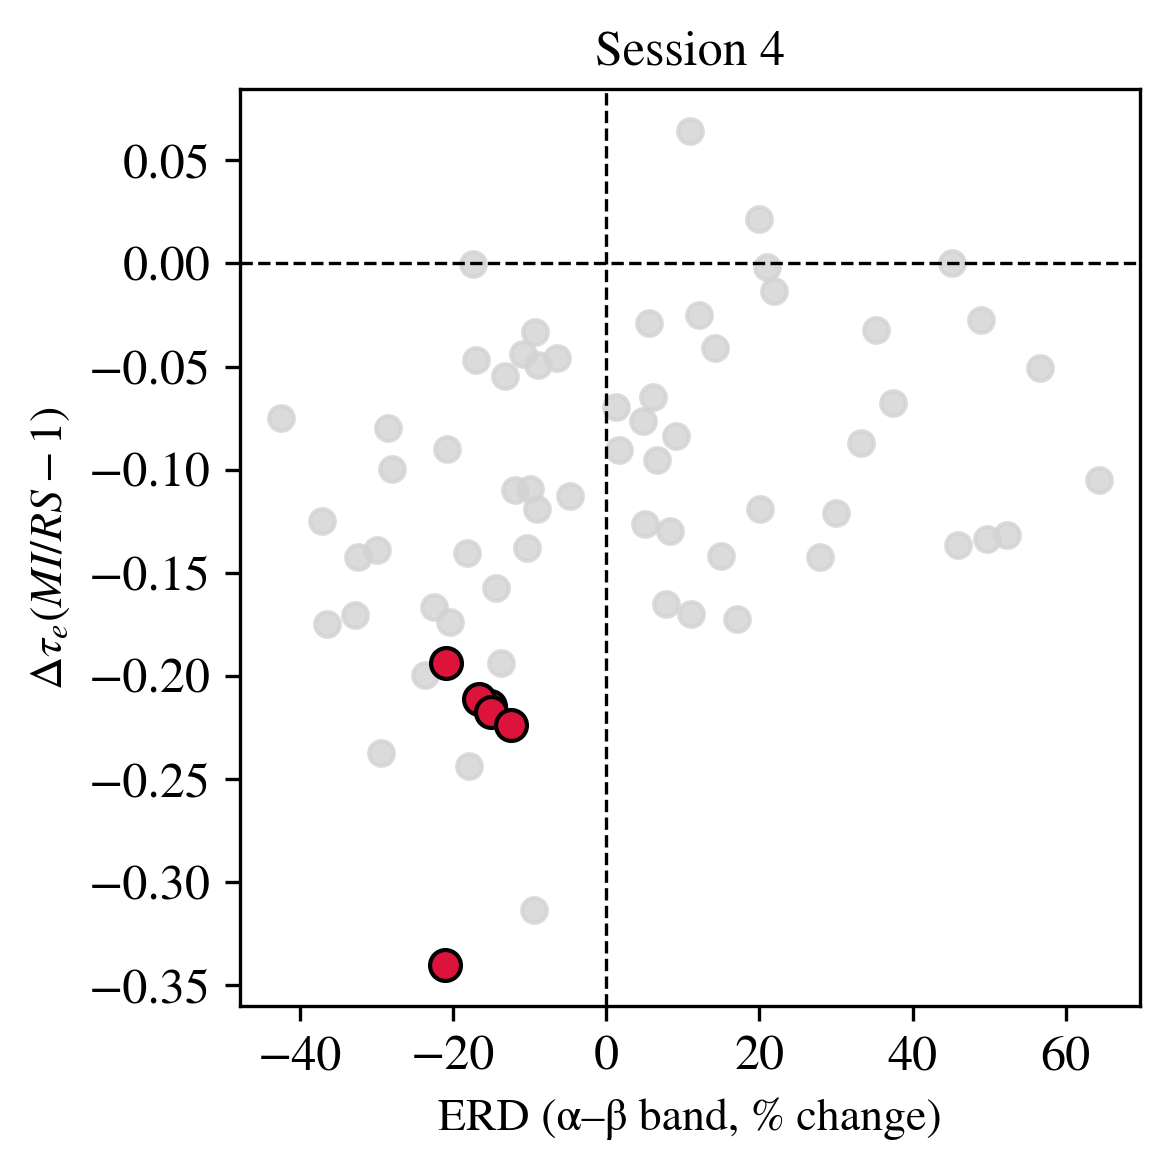

In [211]:
plot_erd_taue_scatter(
    erd_roi[4],
    delta_taue_roi[4],
    motor_rois,
    session=4,
    rho=0.485,
    p=0.0001
)



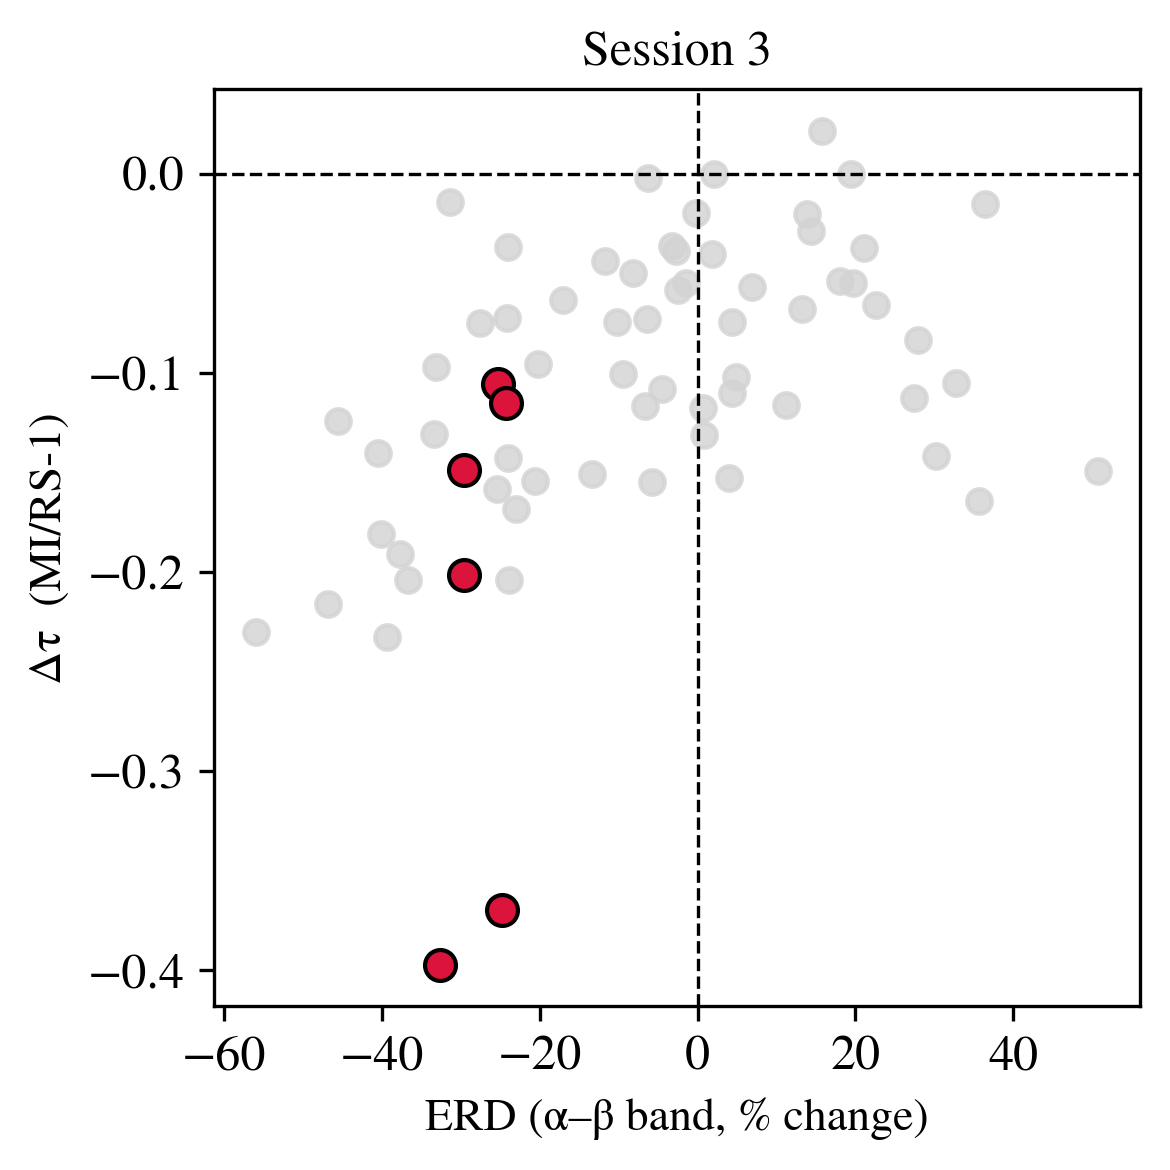

In [206]:
plot_erd_taue_scatter(
    erd_roi[3],
    delta_taue_roi[3],
    motor_rois,
    session=3,
    rho=0.485,
    p=0.0001
)



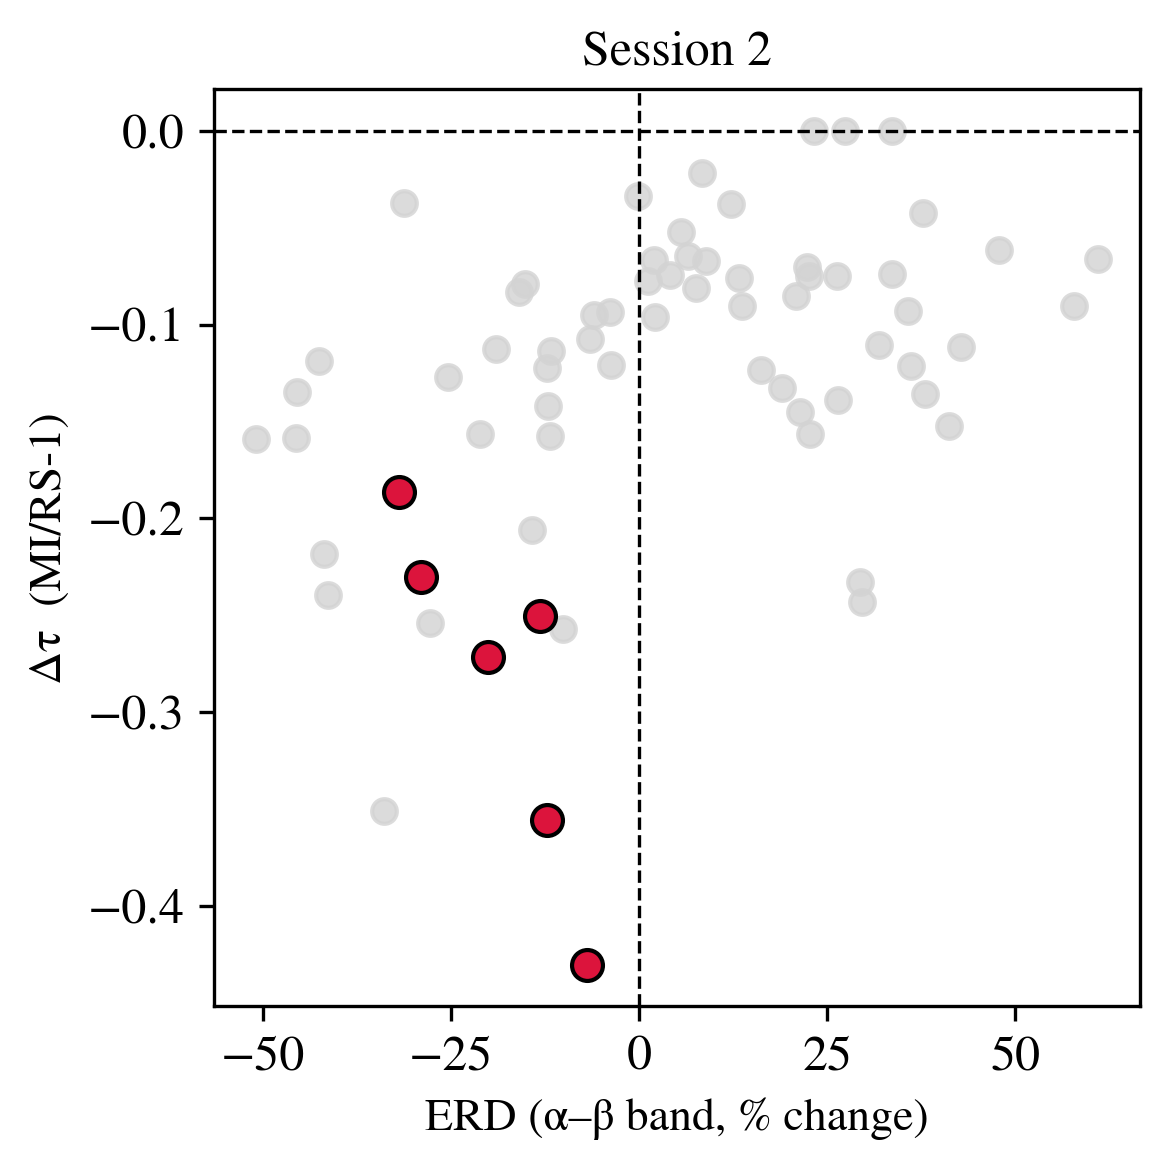

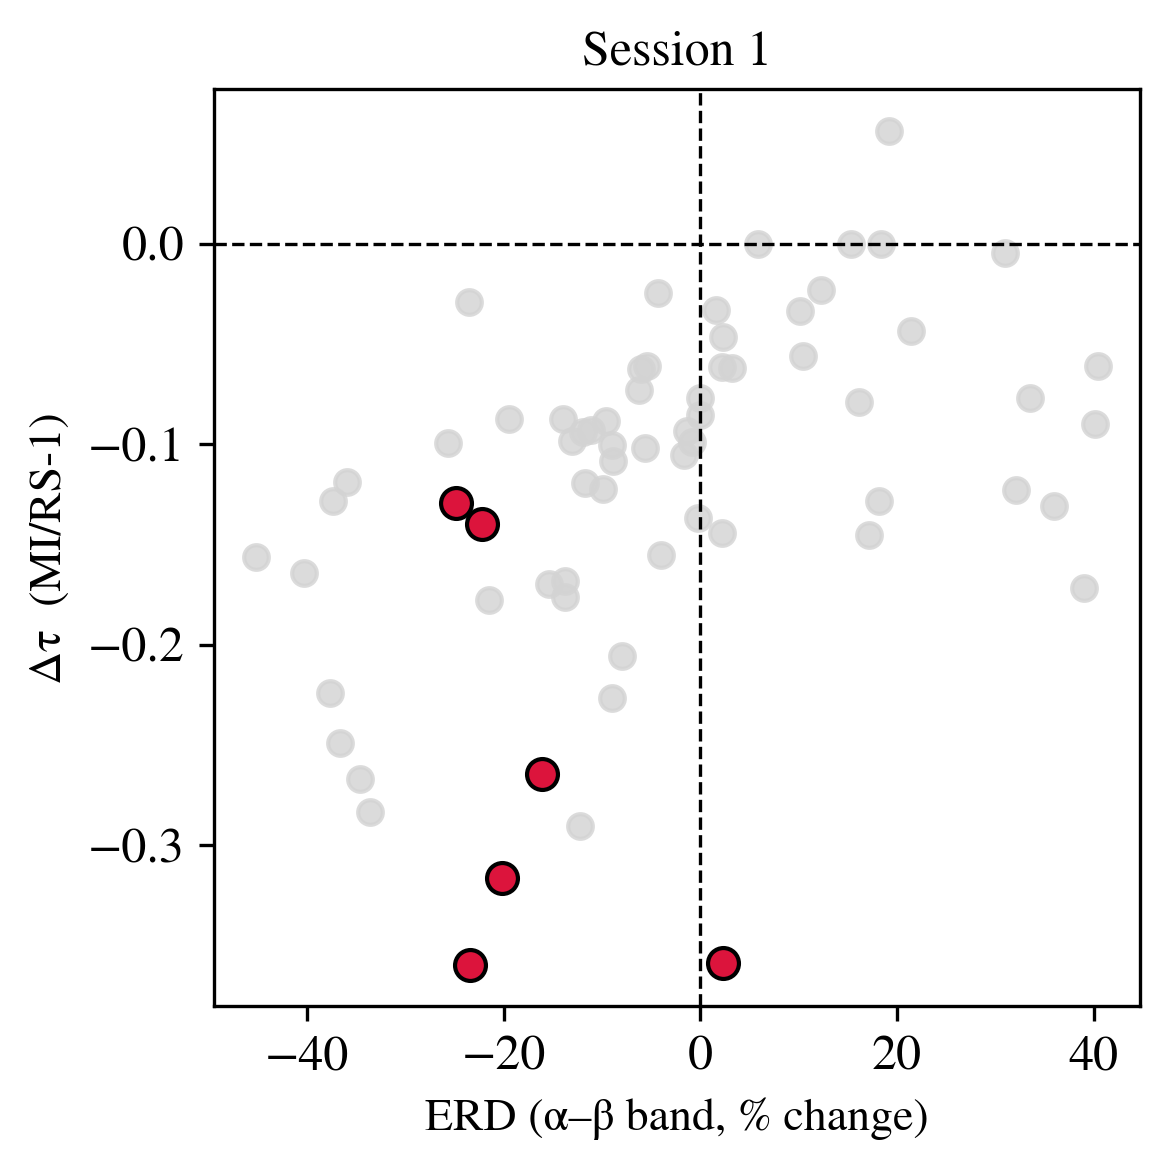

In [207]:
plot_erd_taue_scatter(
    erd_roi[2],
    delta_taue_roi[2],
    motor_rois,
    session=2,
    rho=0.485,
    p=0.0001
)

plot_erd_taue_scatter(
    erd_roi[1],
    delta_taue_roi[1],
    motor_rois,
    session=1,
    rho=0.485,
    p=0.0001
)


In [ ]:
# def plot_motor_vs_nonmotor_erd(erd, motor_rois, session):
#     motor = erd[motor_rois]
#     nonmotor = np.delete(erd, motor_rois)

#     plt.figure(figsize=(3,3), dpi=300)
#     plt.boxplot(
#         [motor, nonmotor],
#         labels=['Motor', 'Non-motor'],
#         widths=0.6,
#         showfliers=False,
#         #box color
#     )

#     plt.ylabel('ERD (α–β band, % change)', fontsize=11)
#     plt.title(f'Session {session}', fontsize=12)
#     plt.axhline(0, linestyle='--', color='black', linewidth=0.8)

#     plt.tight_layout()
#     plt.show()


def plot_motor_vs_nonmotor_erd(erd, motor_rois, session):
    motor = erd[motor_rois]
    nonmotor = np.delete(erd, motor_rois)

    plt.figure(figsize=(3,3), dpi=300)

    bp = plt.boxplot(
        [motor, nonmotor],
        labels=['Motor', 'Non-motor'],
        widths=0.6,
        showfliers=False,
        patch_artist=True  # 
    )

    # Set box colors
    colors = ['crimson', "lightgray"]  # red, pale white
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        # box.set_edgecolor('black')
        # box.set_linewidth(1.2)

    # Style other elements
    # for whisker in bp['whiskers']:
    #     whisker.set_color('black')
    #     whisker.set_linewidth(1.0)

    # for cap in bp['caps']:
    #     cap.set_color('black')
    #     cap.set_linewidth(1.0)

    # for median in bp['medians']:
    #     median.set_color('yellow')
    #     median.set_linewidth(1.5)

    plt.ylabel('ERD (α–β band, % change)', fontsize=11)
    plt.title(f'Session {session}', fontsize=12)
    plt.axhline(0, linestyle='--', color='black', linewidth=0.8)

    plt.tight_layout()
    plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_motor_non_motor.png", dpi=600)
    plt.show()


In [198]:
motor_rois

array([32, 33, 44, 45, 48, 49])

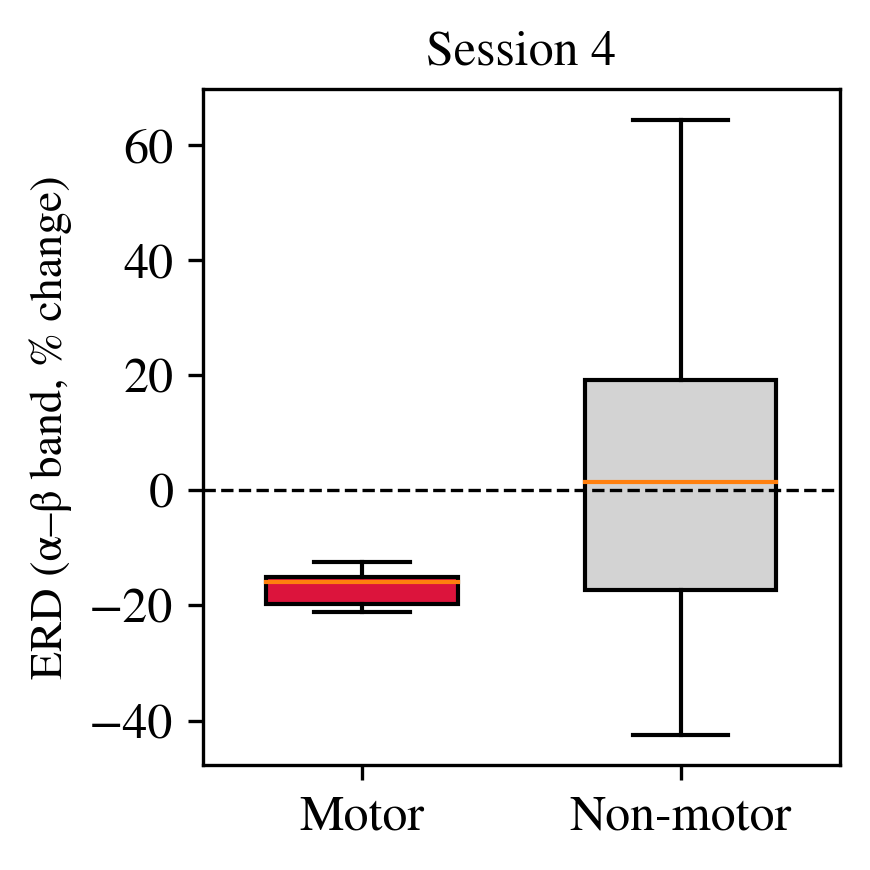

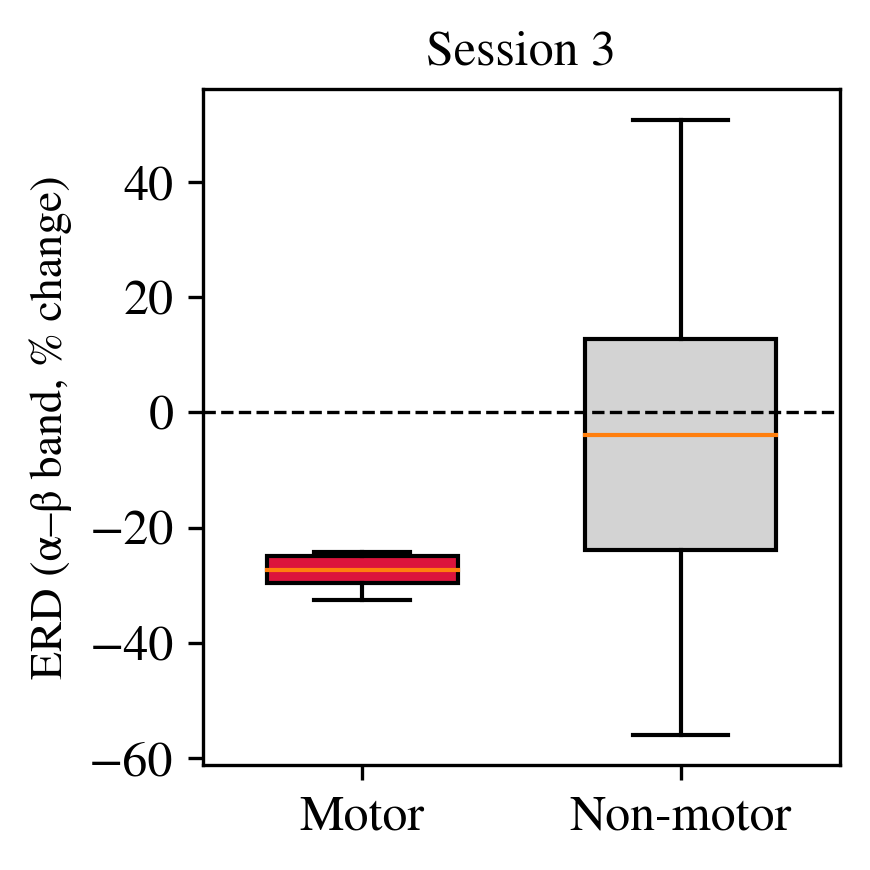

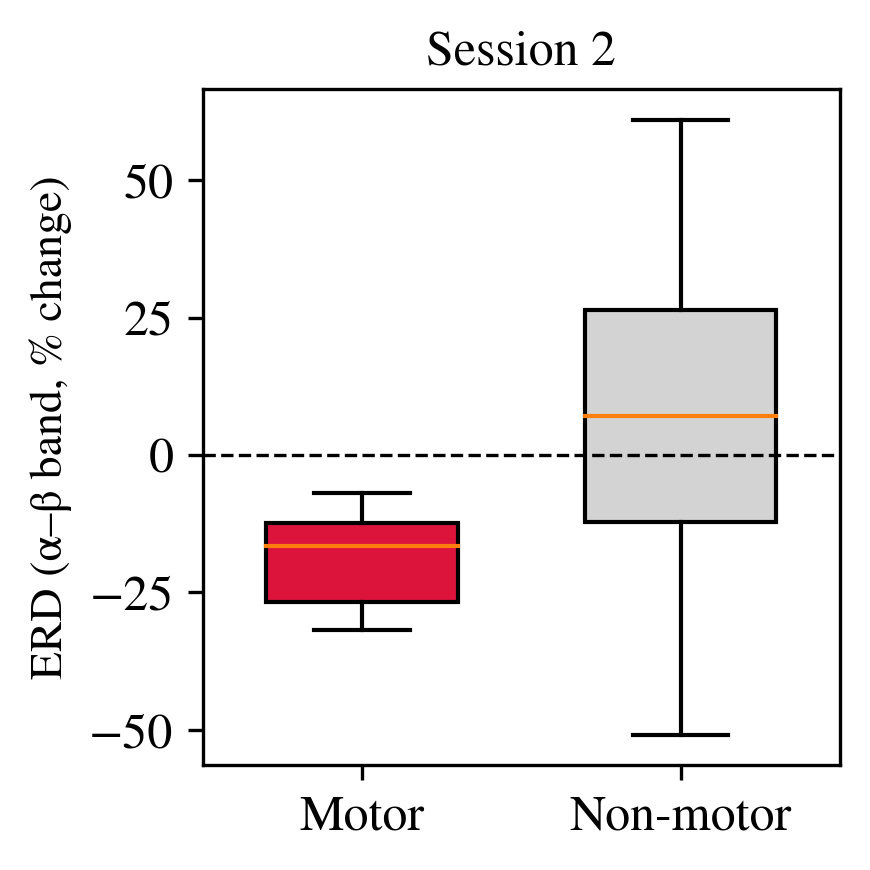

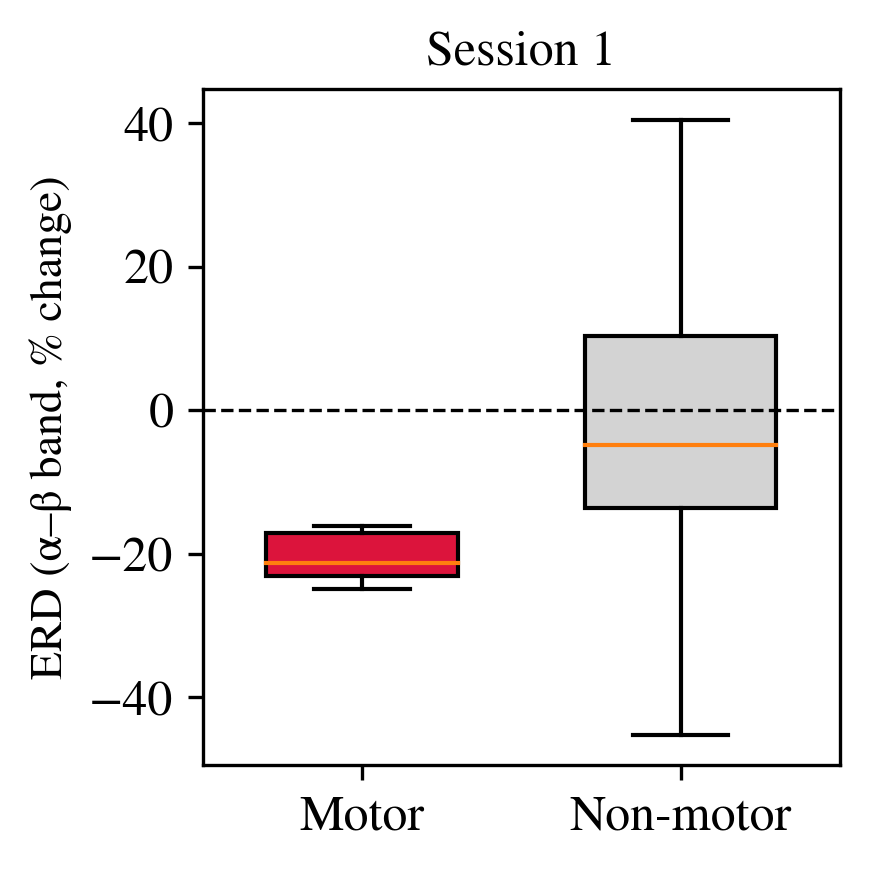

In [199]:
## plot for all 
plot_motor_vs_nonmotor_erd(erd_roi[4], motor_rois, session=4)

plot_motor_vs_nonmotor_erd(erd_roi[3], motor_rois, session=3)
plot_motor_vs_nonmotor_erd(erd_roi[2], motor_rois, session=2)
plot_motor_vs_nonmotor_erd(erd_roi[1], motor_rois, session=1) 



In [336]:
## subject level motor bias across sessions
def plot_motor_bias_across_sessions(motor_bias):
    sessions = sorted(motor_bias.keys())
    data = [motor_bias[s] for s in sessions]

    plt.figure(figsize=(3,3), dpi=300)
    plt.boxplot(data, labels=[f"S{s}" for s in sessions], showfliers=False)

    plt.axhline(0, linestyle='--', color='black', linewidth=0.8)
    plt.ylabel('Motor − Non-motor ERD', fontsize=11)
    plt.title('Subject-level Motor Bias Across Sessions', fontsize=12)

    plt.tight_layout()
    plt.show()


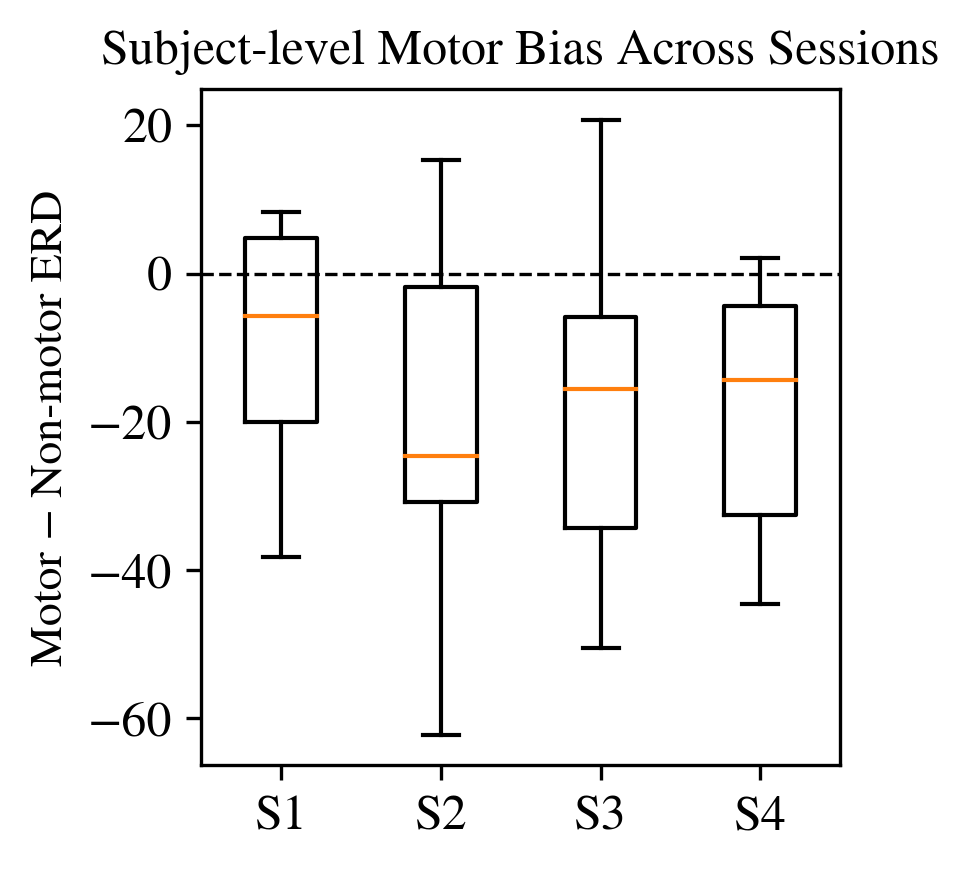

In [103]:
plot_motor_bias_across_sessions(motor_bias)


## G_ei

In [328]:
# shape: (19, 68)
delta_gei = {} 
for s in range(1, 5):
    gei_mi = x_mi_all[s][:, 0, :] / x_rest_all[s][:, 0, :] - 1
    delta_gei[s] = gei_mi.T

#for each region
delta_gei_roi = {}
for s in delta_gei:
    delta_gei_roi[s] = np.median(delta_gei[s], axis=0)

In [329]:
delta_gei[4]

array([[-9.84820575e-01, -9.98510358e-01, -3.23052274e-01, ...,
        -5.23464127e-01, -9.52403236e-01, -5.52631735e-01],
       [-5.22490127e-01,  2.04504779e+01, -4.56562367e-02, ...,
         4.99000000e+02, -7.64770698e-02, -1.08147633e-01],
       [-9.95665126e-01, -3.55038060e-02,  1.71572089e-01, ...,
        -9.96200487e-01,  0.00000000e+00,  5.36868756e+02],
       ...,
       [-9.29303002e-02,  1.75053186e+02,  3.71167988e+02, ...,
        -2.20693008e-01,  4.70288269e-01,  1.63014408e+02],
       [ 1.11261171e-01,  2.37768936e+00, -6.23927118e-01, ...,
        -9.68795290e-01, -2.34095310e-01, -5.25228214e-01],
       [-1.31605262e-01, -9.95600401e-01,  0.00000000e+00, ...,
         9.73754368e-02, -5.74019573e-02, -9.96466124e-01]])

In [322]:
#Find the regions that shows positive and negative change in GEI
negative_gei_regions = {}
positive_gei_regions = {}
for s in delta_gei_roi:
    # print(f"Session {s}:")
    idx_pos = np.where(delta_gei_roi[s] >= 0)[0]
    idx_neg = np.where(delta_gei_roi[s] < 0)[0]
    region_pos = [all_regions[i].strip(" '' ") for i in idx_pos]
    region_neg = [all_regions[i].strip(" '' ") for i in idx_neg]
    negative_gei_regions[s] = region_neg
    positive_gei_regions[s] = region_pos


In [334]:
np.array(negative_gei_regions[3])

array(['caudalanteriorcingulate L', 'caudalanteriorcingulate R',
       'caudalmiddlefrontal L', 'caudalmiddlefrontal R', 'frontalpole L',
       'frontalpole R', 'fusiform L', 'inferiortemporal L', 'insula L',
       'lateralorbitofrontal R', 'medialorbitofrontal L',
       'middletemporal L', 'middletemporal R', 'parahippocampal L',
       'parsopercularis L', 'parsopercularis R', 'parsorbitalis R',
       'parstriangularis L', 'parstriangularis R', 'posteriorcingulate L',
       'precentral L', 'precuneus R', 'rostralanteriorcingulate L',
       'rostralanteriorcingulate R', 'rostralmiddlefrontal L',
       'superiortemporal L', 'superiortemporal R', 'transversetemporal L',
       'transversetemporal R'], dtype='<U26')

In [330]:
## correlation between ERD and delta gei
erd_gei_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_gei_roi[s])
    erd_gei_corr[s] = {"rho": rho, "p": p}

for s in erd_gei_corr:
    print(f"Session {s}: Spearman rho={erd_gei_corr[s]['rho']:.3f}, "
          f"p={erd_gei_corr[s]['p']:.8f}")



Session 1: Spearman rho=-0.490, p=0.00002253
Session 2: Spearman rho=-0.475, p=0.00004302
Session 3: Spearman rho=-0.415, p=0.00043692
Session 4: Spearman rho=-0.176, p=0.15082044


In [332]:
#Find the regions coresponding to +ve ERD for taue
regions_list = {}
for s in erd_roi:
    # print(f"Session {s}:")
    idx = np.where(erd_roi[s] > 0)[0]
    region = [all_regions[i].strip(" '' ") for i in idx]
    regions_list[s] = region
   
len(regions_list[4])

32

## G_ii

In [218]:
# shape: (19, 68)
delta_gii = {} 
for s in range(1, 5):
    gii_mi = x_mi_all[s][:, 1, :] / x_rest_all[s][:, 1, :] - 1
    delta_gii[s] = gii_mi.T

#for each region
delta_gii_roi = {}
for s in delta_gii:
    delta_gii_roi[s] = np.median(delta_gii[s], axis=0)

In [337]:
# delta_gii_roi

In [219]:
## correlation between ERD and delta gii
erd_gii_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_gii_roi[s])
    erd_gii_corr[s] = {"rho": rho, "p": p}

for s in erd_gii_corr:
    print(f"Session {s}: Spearman rho={erd_gii_corr[s]['rho']:.3f}, "
          f"p={erd_gii_corr[s]['p']:.8f}")



Session 1: Spearman rho=-0.257, p=0.03464806
Session 2: Spearman rho=-0.217, p=0.07595059
Session 3: Spearman rho=-0.251, p=0.03934269
Session 4: Spearman rho=-0.235, p=0.05378024


In [222]:
# ERD vs delta gei scatter plot
def plot_erd_gei_scatter(erd, dgei, motor_rois, session, rho, p):
    plt.figure(figsize=(4,4), dpi=300)

    all_rois = np.arange(len(erd))
    nonmotor = np.setdiff1d(all_rois, motor_rois)

    # Non-motor ROIs
    plt.scatter(
        erd[nonmotor],
        dgei[nonmotor],
        color='lightgray',
        s=35,
        alpha=0.8,
        label='Non-motor ROIs'
    )

    # Motor ROIs
    plt.scatter(
        erd[motor_rois],
        dgei[motor_rois],
        color='crimson',
        s=55,
        edgecolor='black',
        label='Motor ROIs'
    )

    plt.axhline(0, linestyle='--', linewidth=0.8, color='black')
    plt.axvline(0, linestyle='--', linewidth=0.8, color='black')

    plt.xlabel('ERD (α–β band, % change)', fontsize=11)
    plt.ylabel('$Δg_ei (MI/RS-1)$', fontsize=11)

    plt.title(f'Session {session}', fontsize=12)

    # plt.text(
    #     0.02, 0.95,
    #     f"Spearman ρ = {rho:.2f}\np < 0.001",
    #     transform=plt.gca().transAxes,
    #     fontsize=10,
    #     verticalalignment='top'
    # )

    # plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    # plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_gei_motor_non_motor.png", dpi=600)
    plt.show()


In [338]:
# plot_erd_gei_scatter(
#     erd_roi[1],
#     delta_gei_roi[1],
#     motor_rois,
#     session=4,
#     rho=0.485,
#     p=0.0001
# )

